# DMW Hypomethylation per Cell-Type Cluster

Applies the `identify_relative_lows` approach from `260325_identify_hypo.ipynb` to the
**curated DMW set** (3,124 windows from `chunks_CG_minfilt.gff`) established in
`minfilt_gff_analysis.ipynb`.

**Pipeline:**
1. Load DMW MCDS + RNA + cluster metadata
2. Filter MCDS to the 3,124 curated DMWs
3. Compute logit-adjusted methylation residuals per cluster (per DMW)
4. Map each DMW to overlapping gene(s) via gene-body overlap
5. Identify DMWs with cluster-specific hypomethylation (`identify_relative_lows`)
6. Collapse hypo-DMWs → genes and output per-cluster gene lists

**Before running, verify paths in Cell 2.**

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import xarray as xr
import bioframe as bf
from scipy.stats import zscore
from scipy.special import logit, expit
from ALLCools.mcds import MCDS

In [2]:
# ---- EDIT PATHS HERE ----
mcds_paths = [
    "/ceph/MethDev/pbio/andy/JW/section_4/All_mcds_dmw3_0.mcds",
    "/ceph/MethDev/pbio/andy/JW/section_4/All_mcds_dmw3_1.mcds",
]
gff_path  = "/ceph/MethDev/pbio/andy/JW/section_4/chunks_CG_minfilt.gff"
rna_path  = "/ceph/MethDev/pbio/hazel/count_Arab13_with_TEs.csv"
meta_path = "/ceph/MethDev/pbio/hazel/merged_cluster_assignments.csv"
genes_bed = "/ceph/MethDev/pbio/andy/JW/section_4/genes.fixed.bed"
out_dir   = "./data"   # /ceph/MethDev/pbio/kay/2026/data/

MC_TYPE = "CGN"
MIN_COV = 50
# -------------------------

os.makedirs(out_dir, exist_ok=True)

mcds = MCDS.open(mcds_paths=mcds_paths, var_dim="dmw")
rna  = pd.read_csv(rna_path).T
meta = pd.read_csv(meta_path).set_index("cell_id")

print(f"MCDS dims: {dict(mcds.dims)}")
print(f"RNA: {rna.shape}, Meta: {meta.shape}")
print(f"\nAvailable mc_types:    {mcds.coords['mc_type'].values.tolist()}")
print(f"Available count_types: {mcds.coords['count_type'].values.tolist()}")
print(f"Unique clusters in meta: {sorted(meta['merged_cluster'].unique())}")

MCDS dims: {'cell': 6071, 'count_type': 2, 'dmw': 22467, 'mc_type': 4}
RNA: (6071, 64507), Meta: (5908, 1)

Available mc_types:    ['CHH', 'CHG', 'CHN', 'CGN']
Available count_types: ['mc', 'cov']
Unique clusters in meta: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


In [3]:
# Filter MCDS to curated 3,124 DMWs from chunks_CG_minfilt.gff
try:
    new_dmws = pd.read_csv(
        gff_path, sep="\t", header=None, comment="#",
        usecols=[0, 3, 4], names=["chrom", "start", "end"],
    )
except Exception:
    new_dmws = pd.read_csv(
        gff_path, sep=r"\s+", header=None, comment="#",
        usecols=[0, 3, 4], names=["chrom", "start", "end"],
    )

new_dmws["start"] = new_dmws["start"].astype(int)
new_dmws["end"]   = new_dmws["end"].astype(int)
print(f"Curated chunks in GFF: {len(new_dmws)}")

# Build MCDS coordinate table
dmw_bed_full = pd.DataFrame({
    "chrom":  mcds["dmw_chrom"].values,
    "start":  mcds["dmw_start"].values.astype(int),
    "end":    mcds["dmw_end"].values.astype(int),
    "dmw_id": mcds.get_index("dmw").values,
})

# Harmonize chrom names (GFF uses chr1-style; MCDS uses bare integers)
new_dmws_fixed = new_dmws.copy()
new_dmws_fixed["chrom"] = new_dmws_fixed["chrom"].str.replace("^chr", "", regex=True).astype(str)
new_dmws_fixed["start"] = new_dmws_fixed["start"] + 1   # 0-based BED → 1-based MCDS
dmw_bed_full["chrom"] = dmw_bed_full["chrom"].astype(str)

# Exact-coordinate match
merged = dmw_bed_full.merge(new_dmws_fixed, on=["chrom", "start", "end"], how="inner")
print(f"Exact matches: {len(merged)} / {len(new_dmws_fixed)} curated chunks")

keep_ids = merged["dmw_id"].tolist()
mcds = mcds.sel(dmw=keep_ids)
print(f"Filtered MCDS dims: {dict(mcds.dims)}")

Curated chunks in GFF: 3124
Exact matches: 3124 / 3124 curated chunks
Filtered MCDS dims: {'cell': 6071, 'count_type': 2, 'dmw': 3124, 'mc_type': 4}


In [4]:
# RNA per-cluster matrix (log1p CPM, mean per cluster)
common_cells     = rna.index.intersection(meta.index)
rna_aligned      = rna.loc[common_cells]
cell_totals      = rna_aligned.sum(axis=1)
rna_cpm          = rna_aligned.div(cell_totals, axis=0) * 1e6
rna_log1p        = np.log1p(rna_cpm)
rna_log1p["cluster"] = meta.loc[common_cells, "merged_cluster"]
cluster_rna_matrix   = rna_log1p.groupby("cluster").mean().T   # genes × clusters

print(f"Cells with both RNA and meta: {len(common_cells)}")
print(f"RNA cluster matrix: {cluster_rna_matrix.shape}  (genes × clusters)")

Cells with both RNA and meta: 5908
RNA cluster matrix: (64507, 17)  (genes × clusters)


In [5]:
# DMW methylation residuals per cluster (logit-adjusted)
mCG_mc  = mcds.sel(mc_type=MC_TYPE, count_type="mc").dmw_da.to_pandas()
mCG_cov = mcds.sel(mc_type=MC_TYPE, count_type="cov").dmw_da.to_pandas()

keep = mCG_mc.index.intersection(meta.index)
mCG_mc, mCG_cov = mCG_mc.loc[keep], mCG_cov.loc[keep]
mCG_mc["cluster"]  = meta.loc[keep, "merged_cluster"]
mCG_cov["cluster"] = meta.loc[keep, "merged_cluster"]

cluster_c = mCG_mc.groupby("cluster").sum().T   # dmw × clusters
cluster_m = mCG_cov.groupby("cluster").sum().T

# Global logit offsets
global_c = cluster_c.sum(axis=0)
global_m = cluster_m.sum(axis=0)
global_p = global_c / global_m
d        = logit(np.clip(global_p, 1e-6, 1 - 1e-6))
deltas   = d - np.average(d, weights=global_m)

dmw_c = cluster_c.sum(axis=1)
dmw_m = cluster_m.sum(axis=1)

valid = dmw_m >= MIN_COV
cluster_c, cluster_m = cluster_c[valid], cluster_m[valid]
dmw_c, dmw_m         = dmw_c[valid], dmw_m[valid]
print(f"DMWs passing coverage filter (>= {MIN_COV}): {valid.sum()} / {len(valid)}")

pbar = np.clip(dmw_c / dmw_m, 1e-6, 1 - 1e-6)
expected_logit = logit(pbar).values[:, None] + deltas.values[None, :]
p0_df = pd.DataFrame(expit(expected_logit),
                     index=cluster_c.index, columns=cluster_c.columns)

obs_p           = (cluster_c / cluster_m.replace(0, np.nan)).fillna(0)
adj_meth_matrix = obs_p - p0_df

highly_meth      = obs_p[obs_p.apply(lambda x: (x >= 0.1).any(), axis=1)].index
filtered_meth_df = adj_meth_matrix.loc[highly_meth]
print(f"DMWs after methylation filter (>= 0.1 in at least one cluster): {len(filtered_meth_df)}")

DMWs passing coverage filter (>= 50): 3124 / 3124
DMWs after methylation filter (>= 0.1 in at least one cluster): 3054


In [6]:
# DMW → gene mapping by gene-body overlap
dmw_bed = pd.DataFrame({
    "chrom":  mcds["dmw_chrom"].values,
    "start":  mcds["dmw_start"].values.astype(int),
    "end":    mcds["dmw_end"].values.astype(int),
    "dmw_id": mcds.get_index("dmw").values,
})

genes = pd.read_csv(
    genes_bed, sep="\t", header=None,
    names=["chrom", "start", "end", "gene", "score", "strand"],
    usecols=[0, 1, 2, 3],
)
print(f"Loaded {len(genes)} gene records")

# Harmonize: DMW chroms are bare integers, genes use chr-prefix
dmw_bed["chrom"] = "chr" + dmw_bed["chrom"].astype(str)

assert set(dmw_bed["chrom"]) & set(genes["chrom"]), \
    "No shared chromosome names — harmonize naming before continuing."

overlaps = bf.overlap(
    dmw_bed, genes,
    cols1=("chrom", "start", "end"),
    cols2=("chrom", "start", "end"),
    how="inner",
    suffixes=("_dmw", "_gene"),
)

dmw_col  = next(c for c in overlaps.columns if c.startswith("dmw_id"))
gene_col = next(c for c in overlaps.columns if c == "gene" or c.startswith("gene_"))

dmw_to_gene = (
    overlaps[[dmw_col, gene_col]]
    .rename(columns={dmw_col: "dmw_id", gene_col: "gene"})
    .drop_duplicates()
    .reset_index(drop=True)
)

print(f"DMW-gene overlap pairs: {len(dmw_to_gene)}")
print(f"Unique DMWs with a gene:   {dmw_to_gene['dmw_id'].nunique()}")
print(f"Unique genes hit by a DMW: {dmw_to_gene['gene'].nunique()}")

Loaded 33326 gene records
DMW-gene overlap pairs: 1343
Unique DMWs with a gene:   1233
Unique genes hit by a DMW: 1237


In [7]:
# Cluster naming
cluster_mapping = {
    3: '3 Early M', 0: '0 Mid M', 7: '7 Expanding M', 1: '1 Late M', 10: '10 Senescent M',
    5: '5 Early E', 4: '4 Abaxial E', 6: '6 Adaxial E', 13: '13 Expanding E', 8: '8 Senescent E',
    14: '14 Guard cell', 2: '2 Vasculature', 11: '11 PPP', 9: '9 Phloem',
    16: '16 Myrosinase', 12: '12 S phase', 15: '15 G2M phase'
}
cluster_mapping.update({str(k): v for k, v in cluster_mapping.items()})

cluster_order = [
    '3 Early M', '0 Mid M', '7 Expanding M', '1 Late M', '10 Senescent M',
    '5 Early E', '13 Expanding E', '4 Abaxial E', '6 Adaxial E', '8 Senescent E',
    '14 Guard cell', '2 Vasculature', '11 PPP', '9 Phloem',
    '16 Myrosinase', '12 S phase', '15 G2M phase'
]


def identify_relative_lows(item_list, obs_p, adj_meth_matrix, cluster_m,
                            min_coverage=10,
                            residual_threshold=-0.02,
                            zscore_threshold=-0.5,
                            min_raw_max=0.02):
    """Flag items (genes or DMWs) whose methylation is cluster-specifically low.

    An item qualifies in a cluster when:
      - Raw methylation fraction exceeds min_raw_max in at least one cluster
      - At least 3 clusters have coverage >= min_coverage
      - The cluster's residual <= residual_threshold  (absolute drop)
      - The cluster's within-item z-score <= zscore_threshold  (relative drop)
    """
    results = []
    valid_items = [i for i in item_list if i in adj_meth_matrix.index]

    for item in valid_items:
        item_obs = obs_p.loc[item]
        item_adj = adj_meth_matrix.loc[item]
        item_cov = cluster_m.loc[item]

        if item_obs.max() < min_raw_max:
            continue

        valid_mask = item_cov >= min_coverage
        if valid_mask.sum() < 3:
            continue

        valid_adj   = item_adj[valid_mask]
        adj_zscores = pd.Series(zscore(valid_adj), index=valid_adj.index)

        hypo_clusters = valid_adj[
            (valid_adj <= residual_threshold) & (adj_zscores <= zscore_threshold)
        ].index.tolist()

        for cluster in hypo_clusters:
            results.append({
                'Gene':         item,
                'Cluster':      cluster,
                'Raw_Fraction': item_obs[cluster],
                'Residual':     valid_adj[cluster],
                'Z_Score':      adj_zscores[cluster],
                'Coverage':     item_cov[cluster],
            })

    if not results:
        return pd.DataFrame()
    return pd.DataFrame(results).sort_values(by=['Gene', 'Residual'])

In [8]:
# Run identify_relative_lows on all filtered DMWs
# Adjust thresholds here if needed
all_dmw_ids = filtered_meth_df.index.tolist()

all_hypo_results = identify_relative_lows(
    all_dmw_ids,
    obs_p           = obs_p,
    adj_meth_matrix = adj_meth_matrix,
    cluster_m       = cluster_m,
    residual_threshold = -0.02,
    zscore_threshold   = -0.5,
    min_raw_max        = 0.02,
)

all_hypo_results = all_hypo_results.rename(columns={"Gene": "DMW"})

print(f"Total hypomethylation events (DMW × cluster): {len(all_hypo_results)}")
print(f"Unique hypo-DMWs: {all_hypo_results['DMW'].nunique()}")
display(all_hypo_results.head(10))

Total hypomethylation events (DMW × cluster): 13608
Unique hypo-DMWs: 3006


,DMW,Cluster,Raw_Fraction,Residual,Z_Score,Coverage
5731,dmw=10088,10,0.269036,-0.158950,-1.623124,197
5732,dmw=10088,13,0.450000,-0.129351,-1.292372,140
5728,dmw=10088,2,0.464368,-0.123462,-1.226566,435
5730,dmw=10088,8,0.373391,-0.088668,-0.837757,233
5734,dmw=10088,16,0.400000,-0.086126,-0.809351,50
5729,dmw=10088,7,0.568807,-0.060214,-0.519797,327
5733,dmw=10088,15,0.563636,-0.058452,-0.500116,55
5738,dmw=10125,14,0.154839,-0.207756,-2.947024,155
5737,dmw=10125,13,0.212042,-0.082357,-1.025840,382
5735,dmw=10125,6,0.203097,-0.073947,-0.896997,1098


In [9]:
# Map hypo-DMWs back to genes via dmw_to_gene
hypo_with_genes = all_hypo_results.merge(
    dmw_to_gene, left_on="DMW", right_on="dmw_id", how="left"
)

# Keep one row per (gene, cluster) — most negative residual wins when
# the same gene is hit by multiple hypo-DMWs in the same cluster
hypo_gene_events = (
    hypo_with_genes
    .dropna(subset=["gene"])
    [["gene", "Cluster", "DMW", "Residual", "Z_Score", "Coverage"]]
    .sort_values(["Cluster", "Residual"])          # most-negative residual first
    .drop_duplicates(subset=["gene", "Cluster"])   # keep first (most negative)
    .reset_index(drop=True)
)

print(f"Unique (gene, cluster) hypomethylation events: {len(hypo_gene_events)}")
print(f"Unique genes flagged across all clusters: {hypo_gene_events['gene'].nunique()}")

# Assemble wide per-cluster DataFrame (matches 260325 output structure)
cluster_gene_dict = {}
for cluster_id, group in hypo_gene_events.groupby("Cluster"):
    cluster_name = cluster_mapping.get(cluster_id, str(cluster_id))
    cluster_gene_dict[cluster_name] = group["gene"].unique().tolist()

hypo_genes_df = pd.DataFrame(
    {c: pd.Series(g) for c, g in cluster_gene_dict.items()}
)
valid_cols = [c for c in cluster_order if c in hypo_genes_df.columns]
hypo_genes_df = hypo_genes_df[valid_cols]

display(hypo_genes_df.head(10))

Unique (gene, cluster) hypomethylation events: 5751
Unique genes flagged across all clusters: 1146


,3 Early M,0 Mid M,7 Expanding M,1 Late M,10 Senescent M,5 Early E,13 Expanding E,4 Abaxial E,6 Adaxial E,8 Senescent E,14 Guard cell,2 Vasculature,11 PPP,9 Phloem,16 Myrosinase,12 S phase,15 G2M phase
0,AT2G07725,AT3G14210,AT5G42940,AT3G14210,AT2G13430,AT2G07648,AT5G42940,AT3G26450,AT3G26450,AT1G65070,AT2G07665,AT1G62560,AT2G01990,AT2G01990,AT2G14255,AT2G07646,AT2G07827
1,AT1G58300,AT4G01130,AT3G20890,AT4G13575,AT2G10553,AT2G07775,AT1G45191,AT3G26440,AT3G26440,AT1G21060,AT2G00500,AT2G01990,AT5G35670,AT5G07605,AT1G65840,AT2G07656,AT5G38190
2,AT4G01130,AT2G10940,AT5G14610,AT2G10940,AT1G73630,AT2G07695,AT3G26450,AT3G23450,AT1G65070,AT1G08840,AT1G08833,AT1G49225,AT3G44440,AT3G47110,AT5G32590,AT5G42635,AT2G00510
3,AT2G07646,AT1G58300,AT4G01130,AT4G01130,AT1G34370,AT2G07763,AT3G26440,AT1G45191,AT5G48880,AT1G36160,AT1G09805,AT1G49230,AT3G62940,AT2G07646,AT3G02370,AT2G07714,AT2G07665
4,AT2G07648,AT3G45140,AT1G01780,AT3G46668,AT1G32000,AT2G05375,AT2G23080,AT1G65070,AT4G04840,AT4G14548,AT2G07642,AT5G15840,AT5G05730,AT2G07643,AT4G00580,AT5G35670,AT2G00500
5,AT2G07827,AT5G54800,AT1G01770,AT3G46670,AT1G30360,AT2G00510,AT3G03380,AT1G62035,AT3G13510,AT5G50860,AT5G52920,AT5G15843,AT2G07646,AT2G07718,AT1G32000,AT3G01370,AT2G07648
6,AT3G20362,AT3G46668,AT1G09760,AT5G24210,AT5G28410,AT2G07806,AT1G01780,AT1G21980,AT1G45191,AT3G26450,AT2G07648,AT5G38190,AT1G31500,AT1G62560,AT5G15840,AT2G07827,AT2G07738
7,AT2G07656,AT3G46670,AT2G10940,AT5G27950,AT1G44810,AT2G07655,AT1G01770,AT1G01180,AT1G62035,AT3G26440,AT1G01780,AT2G07656,AT5G23050,AT2G07721,AT5G15843,AT1G05313,AT2G07795
8,AT2G10553,AT5G38865,AT2G32710,AT2G01918,AT1G06837,AT2G07738,AT3G23450,AT1G17920,AT5G43130,AT1G62035,AT1G01770,AT2G07827,AT1G16670,AT2G10550,AT1G18050,AT2G07721,AT2G07806
9,AT5G26030,AT5G38860,AT5G15780,AT1G11860,AT1G06833,AT2G07656,AT5G16290,AT1G08840,AT3G27400,AT1G55250,AT3G26450,AT1G74090,AT2G14750,AT2G07795,AT5G06170,AT2G07738,AT2G07642


In [10]:
# Save outputs

# Gene-level: wide format, one column per cluster (matches 260325 CSV structure)
out_genes = f"{out_dir}/hypomethylated_genes_via_dmw_by_cluster.csv"
hypo_genes_df.to_csv(out_genes, index=False)
print(f"Saved gene-level CSV: {out_genes}")

# DMW-level: raw events table for traceability
out_dmw = f"{out_dir}/hypomethylated_dmw_events.csv"
(
    hypo_with_genes
    .dropna(subset=["gene"])
    [["DMW", "gene", "Cluster", "Raw_Fraction", "Residual", "Z_Score", "Coverage"]]
    .sort_values(["Cluster", "Residual"])
    .to_csv(out_dmw, index=False)
)
print(f"Saved DMW-level events CSV: {out_dmw}")

Saved gene-level CSV: ./data/hypomethylated_genes_via_dmw_by_cluster.csv
Saved DMW-level events CSV: ./data/hypomethylated_dmw_events.csv


--- Hypomethylation Summary (DMW-based) ---
Unique genes flagged: 1146

Genes per cluster:
3 Early M         249
0 Mid M           184
7 Expanding M     436
1 Late M          273
10 Senescent M    395
5 Early E         247
13 Expanding E    515
4 Abaxial E       498
6 Adaxial E       541
8 Senescent E     529
14 Guard cell     468
2 Vasculature     177
11 PPP            251
9 Phloem          195
16 Myrosinase     195
12 S phase        274
15 G2M phase      324

Distribution of clusters per gene:
Cluster
1       3
2      25
3      99
4     256
5     362
6     289
7      82
8      16
9      10
10      3
11      1


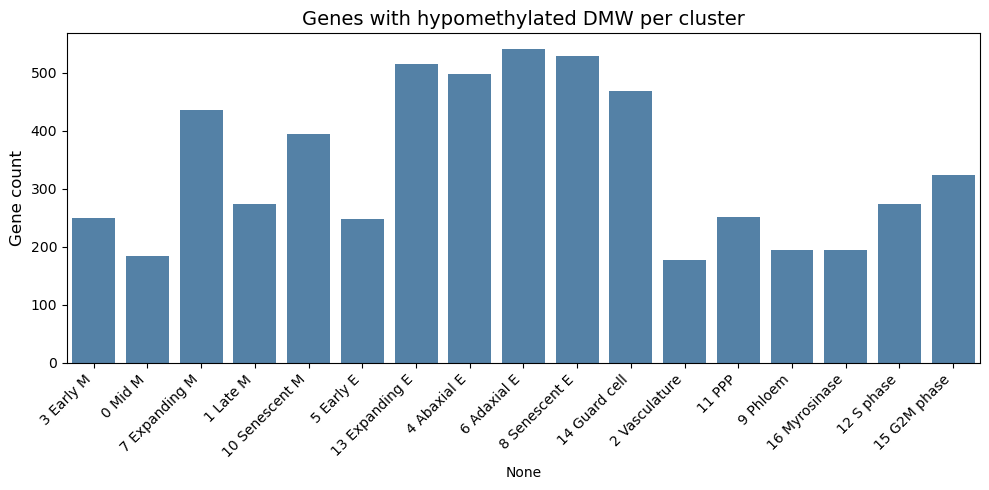

In [11]:
# Summary: genes per cluster
genes_per_cluster = hypo_genes_df.count()

print("--- Hypomethylation Summary (DMW-based) ---")
print(f"Unique genes flagged: {hypo_gene_events['gene'].nunique()}")
print(f"\nGenes per cluster:")
print(genes_per_cluster.to_string())

cluster_counts_per_gene = hypo_gene_events.groupby("gene")["Cluster"].nunique()
print(f"\nDistribution of clusters per gene:")
print(cluster_counts_per_gene.value_counts().sort_index().to_string())

plt.figure(figsize=(10, 5))
sns.barplot(x=genes_per_cluster.index, y=genes_per_cluster.values, color="steelblue")
plt.title("Genes with hypomethylated DMW per cluster", fontsize=14)
plt.ylabel("Gene count", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()